Importing All required packages- Numpy, Pandas, Matplotlib, Seaborn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
print(pd.__version__)                         # Checking the versions
print(np.__version__)

2.2.2
1.26.4


DATA LOADING

In [5]:
df= pd.read_csv('retail_store_sales.csv')               # Load Data


DATA EXPLORING

In [9]:
print(df.head())                # View first five rows

print(df.info())                # Summary

print(f"\n Columns: {df.columns.to_list()}")       # List of all the Columns

print(f"\n Shape of the data: {df.shape}")         # Shape of the Data


  Transaction ID Customer ID       Category          Item  Price Per Unit  \
0    TXN_6867343     CUST_09     Patisserie   Item_10_PAT            18.5   
1    TXN_3731986     CUST_22  Milk Products  Item_17_MILK            29.0   
2    TXN_9303719     CUST_02       Butchers   Item_12_BUT            21.5   
3    TXN_9458126     CUST_06      Beverages   Item_16_BEV            27.5   
4    TXN_4575373     CUST_05           Food   Item_6_FOOD            12.5   

   Quantity  Total Spent  Payment Method Location Transaction Date  \
0      10.0        185.0  Digital Wallet   Online       2024-04-08   
1       9.0        261.0  Digital Wallet   Online       2023-07-23   
2       2.0         43.0     Credit Card   Online       2022-10-05   
3       9.0        247.5     Credit Card   Online       2022-05-07   
4       7.0         87.5  Digital Wallet   Online       2022-10-02   

  Discount Applied  
0             True  
1             True  
2            False  
3              NaN  
4          

DATA CLEANING

In [15]:
# Convert 'Transaction Date' to datetime format

df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])

In [54]:
# Handling Missing Values

# print(df.isnull().sum())            # Check missing values

df['Item']= df['Item'].fillna("Unknown")       # Fill Item with Unknown

df['Price Per Unit']= df['Price Per Unit'].fillna(df['Price Per Unit'].median())      # Fill Price, Qty & Total Spent with Median
df['Quantity']= df['Quantity'].fillna(df['Quantity'].median())
df['Total Spent']= df['Total Spent'].fillna(df['Total Spent'].median())

df['Discount Applied']=  df['Discount Applied'].fillna("False")        # Fill Discount with False

print("Missing Values: ")
print(df.isnull().sum())             # Checking again 

Missing Values: 
Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
Month               0
dtype: int64


In [23]:
print("\nUnique Category Values: ")             # Unique Values for Category

print(df['Category'].value_counts())


Unique Category Values: 
Category
Furniture                             1591
Electric household essentials         1591
Food                                  1588
Milk Products                         1584
Butchers                              1568
Beverages                             1567
Computers and electric accessories    1558
Patisserie                            1528
Name: count, dtype: int64


CALCULATING MEASURES OF CENTRAL TENDENCY & VARIABILITY

In [25]:
print(f"\n {df.describe()} ")            # Describe all Numerical data

print(f"\n {df.describe(include=object)} ")      # Describe all Non- numerical data

print(f"\n {df.head(10)}")             # First 10 rows


        Price Per Unit      Quantity   Total Spent  \
count    12575.000000  12575.000000  12575.000000   
mean        23.348191      5.558648    128.636581   
min          5.000000      1.000000      5.000000   
25%         14.000000      3.000000     55.000000   
50%         23.000000      6.000000    108.500000   
75%         32.000000      8.000000    184.000000   
max         41.000000     10.000000    410.000000   
std         10.480413      2.790160     92.557580   

                    Transaction Date  
count                          12575  
mean   2023-07-12 20:23:41.105368064  
min              2022-01-01 00:00:00  
25%              2022-09-30 00:00:00  
50%              2023-07-13 00:00:00  
75%              2024-04-24 00:00:00  
max              2025-01-18 00:00:00  
std                              NaN   

        Transaction ID Customer ID   Category     Item Payment Method Location  \
count           12575       12575      12575    12575          12575    12575   
uniq

DATA VISUALISATION

In [27]:
# Set seaborn theme for better visuals

sns.set_theme(style="whitegrid")

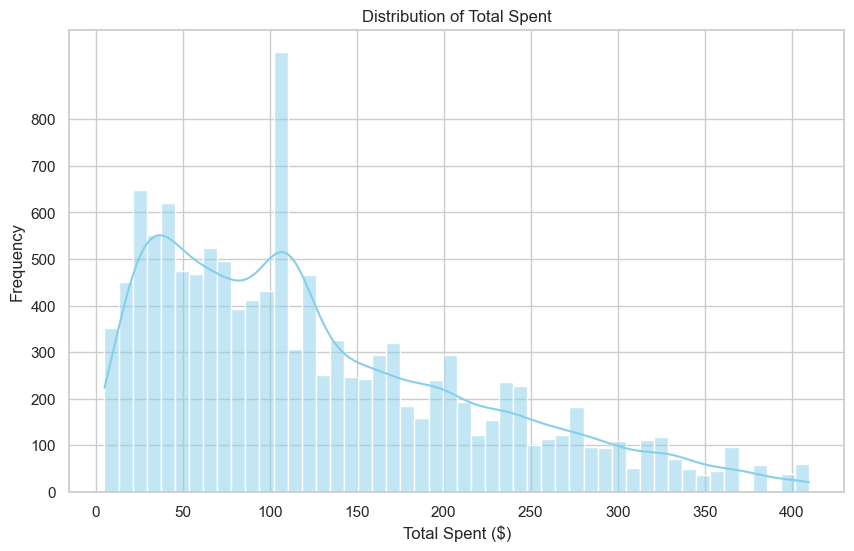

In [29]:
# Distribution of Total Spent

plt.figure(figsize=(10,6))        # Set Figure size
sns.histplot(df['Total Spent'], bins=50,  kde=True, color="skyblue")
plt.yticks([0,100,200,300,400,500,600,700,800])     # Gives Y-axis a specific range 
plt.xlabel('Total Spent ($)')                       # Label X-asis
plt.ylabel('Frequency')                             # Label Y-axis
plt.title('Distribution of Total Spent')            # Gives Title
plt.show()

Top 5 Revenue Generating Categories

In [31]:
# Grouping Category based on Total Spent

top_catg= df.groupby('Category')['Total Spent'].sum().sort_values(ascending=False).head(5)     # Top 5 Descending
print(top_catg)

Category
Butchers                         215930.0
Electric household essentials    211951.0
Beverages                        204751.0
Food                             203600.5
Furniture                        202471.0
Name: Total Spent, dtype: float64


Bar Chart

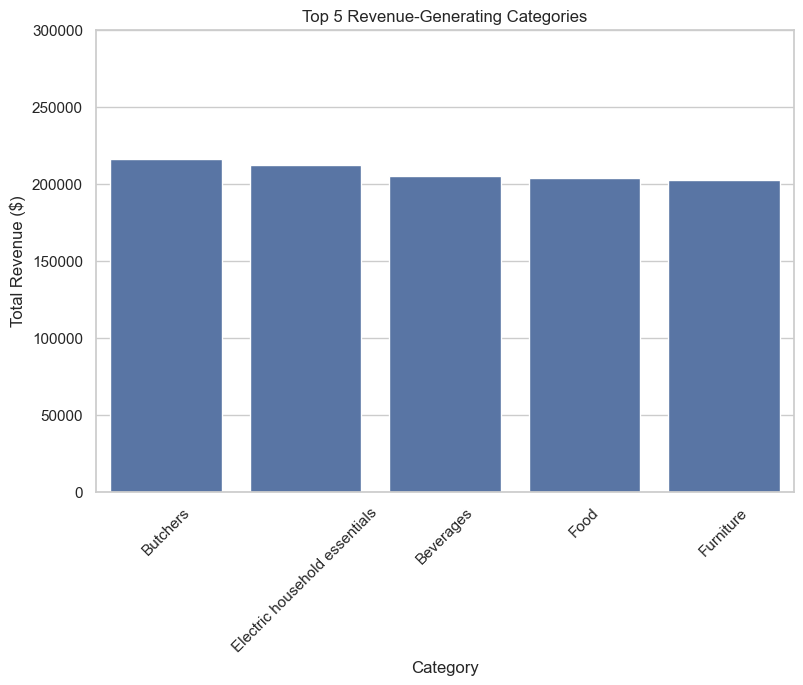

In [33]:
# Bar chart showing Top 5 revenue-generating categories

plt.figure(figsize=(9, 6))
sns.barplot(x=top_catg.index, y=top_catg.values)
plt.ylim(0,300000)                                 # Sets Range limit of Y-axis
plt.title("Top 5 Revenue-Generating Categories")   # Gives Title
plt.xlabel("Category")                             # Label X-asis
plt.ylabel("Total Revenue ($)")                    # Label Y-asis
plt.xticks(rotation=45)
plt.show()

 Pie Chart

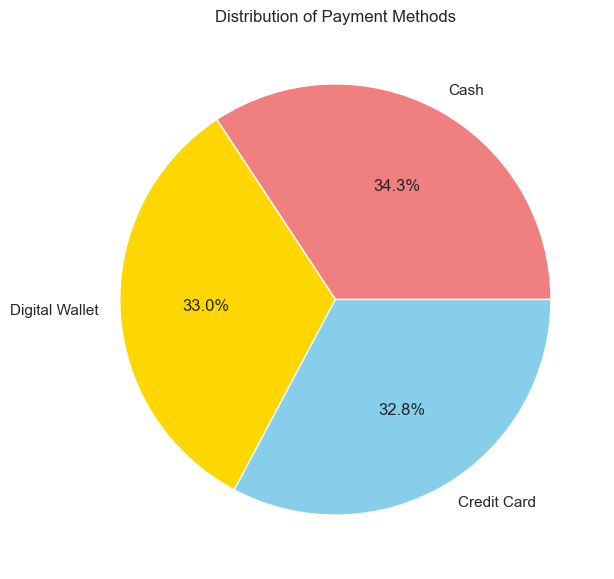

In [35]:
# Pie Chart for showingvDistribution of Payments

payment_counts = df["Payment Method"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', colors=["lightcoral", "gold", "skyblue"])
plt.title("Distribution of Payment Methods")
plt.show()



Box Plot

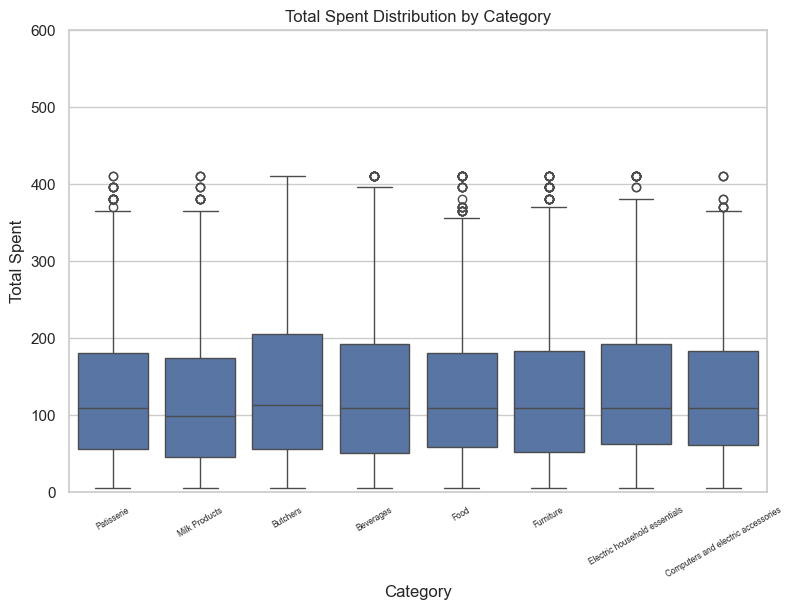

In [37]:
# Box Plot Total Spent By Category

plt.figure(figsize=(9, 6))
sns.boxplot(x="Category", y="Total Spent", data=df)
plt.title("Total Spent Distribution by Category")
plt.xticks(rotation=30,fontsize=6)
plt.ylim(0,600)
plt.show()

Finding and removing possible Outliers


Outliers:
Number of negative outliers: 0
Number of positive outliers: 157


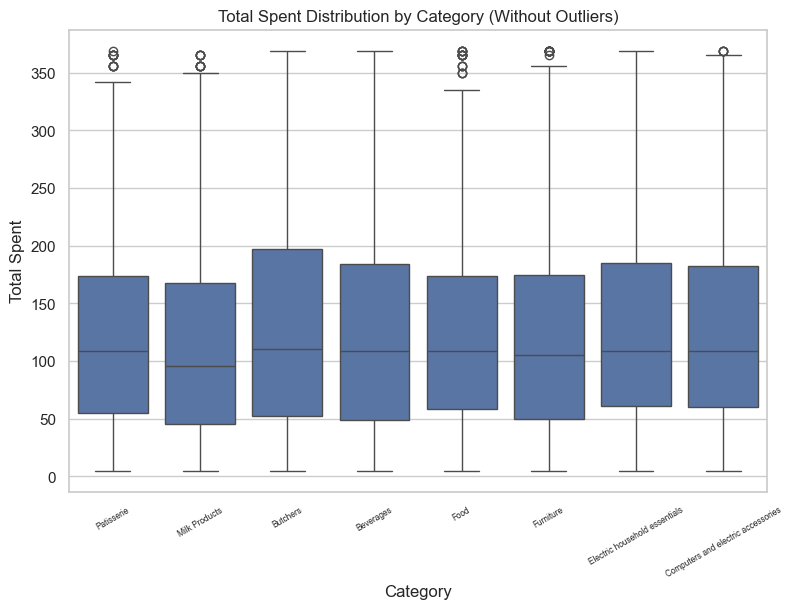

In [56]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df["Total Spent"].quantile(0.25)
Q3 = df["Total Spent"].quantile(0.75)

# Compute Interquartile Range (IQR)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Check outliers specifically
negative_out= df[df['Total Spent'] < lower_bound]
positive_out= df[df['Total Spent'] > upper_bound]

print("\nOutliers:")
print(f"Number of negative outliers: {len(negative_out)}")
print(f"Number of positive outliers: {len(positive_out)}")

# Filter dataset to remove outliers
df_filtered = df[(df["Total Spent"] >= lower_bound) & (df["Total Spent"] <= upper_bound)]

# Plot the boxplot without outliers
plt.figure(figsize=(9, 6))
sns.boxplot(x="Category", y="Total Spent", data=df_filtered)
plt.title("Total Spent Distribution by Category (Without Outliers)")
plt.xticks(rotation=30,fontsize=6)  # Adjust label size
plt.show()


Line Chart

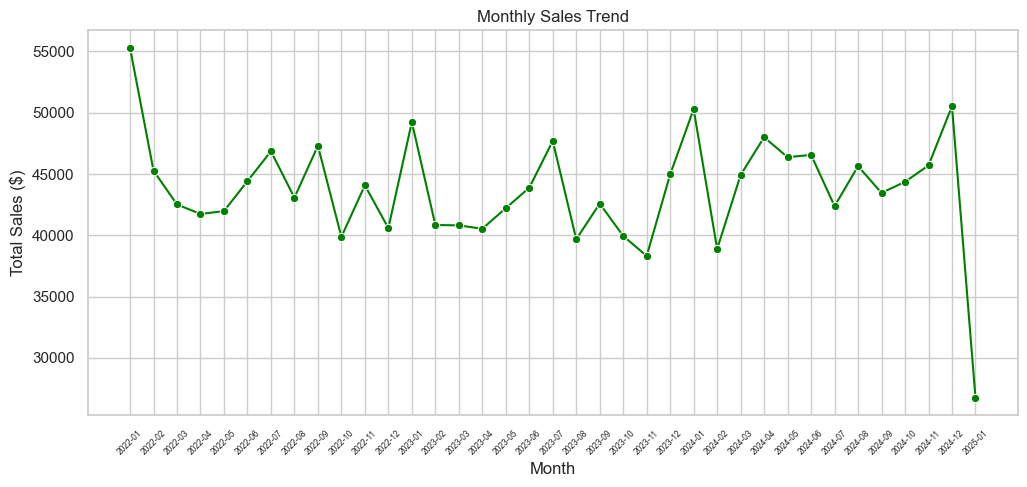

In [51]:
# Line Chart to show Monthly Sales Trend

df["Month"] = df["Transaction Date"].dt.to_period("M")
monthly_sales = df.groupby("Month")["Total Spent"].sum()

plt.figure(figsize=(12, 5))
sns.lineplot(x=monthly_sales.index.astype(str), y=monthly_sales.values, marker="o", color="green")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45,fontsize= 6)
plt.show()

Scatter Plot 

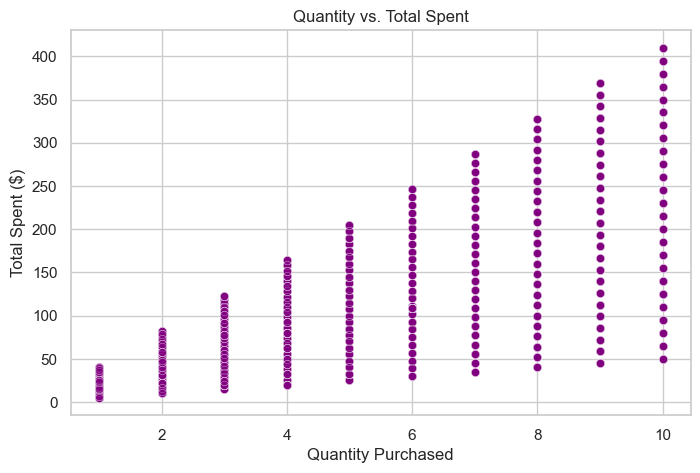

In [47]:
# Scatter Plot to show Quantity vs Total Spent

plt.figure(figsize=(8, 5))
sns.scatterplot(x="Quantity", y="Total Spent", data=df, alpha=0.5, color="purple")
plt.title("Quantity vs. Total Spent")
plt.xlabel("Quantity Purchased")
plt.ylabel("Total Spent ($)")
plt.show()